# G0 — Baseline 1X2 (ventaja de local + tabla)

El **piso a vencer**. Construye, de menor a mayor info:
1. **Tasa base por liga** (constante) — el floor absoluto.
2. **Logística multinomial sobre `Δppg`** (puntos-por-partido local − visita, *point-in-time*).

Evaluación honesta: entrena con 2025, testea con 2026 (features sin leakage),
métricas **RPS** + **log-loss** vs la tasa base.

Requiere: `pandas numpy matplotlib scikit-learn`.

In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Encontrar loader.py (corre desde la carpeta o desde un padre)
here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "loader.py").exists():
        sys.path.insert(0, str(p)); break
import loader

df = loader.load_matches()          # master de partidos jugados (2025+2026)
print("partidos:", df.shape)
df.head(3)

partidos: (1181, 20)


,season,league_code,league_name,competition_id,group_id,group_name,round,match_id,date,time,home_team_id,home_team,away_team_id,away_team,home_goals,away_goals,ht_home,ht_away,status,result
0,2026,VL,Veikkausliiga (M1),spljp26,1,Runkosarja,14,4036852,2026-04-04,13:00:00,60987,Football Club International Turku,60901,Vaasan Palloseura,0,0,0,0,Played,D
1,2026,VL,Veikkausliiga (M1),spljp26,1,Runkosarja,14,4036853,2026-04-04,15:00:00,60731,Helsingin Jalkapalloklubin Liiga-HJK,60970,SEINÄJOEN JALKAPALLOKERHO,3,0,1,0,Played,H
2,2026,VL,Veikkausliiga (M1),spljp26,1,Runkosarja,14,4036854,2026-04-04,17:00:00,60759,IFK Mariehamn Fotboll,60971,TPS Juniorijalkapallo,1,1,1,0,Played,D


## 1. EDA — resultado por liga y ventaja de local

H/D/A global: {'H': 0.478, 'D': 0.187, 'A': 0.334}
goles prom  local: 2.01  visita: 1.6  (ventaja +0.41)
result           H      D      A
league_code                     
M1           0.500  0.199  0.301
M1L          0.433  0.250  0.317
M2           0.495  0.146  0.359
NL           0.534  0.102  0.364
VL           0.434  0.247  0.319


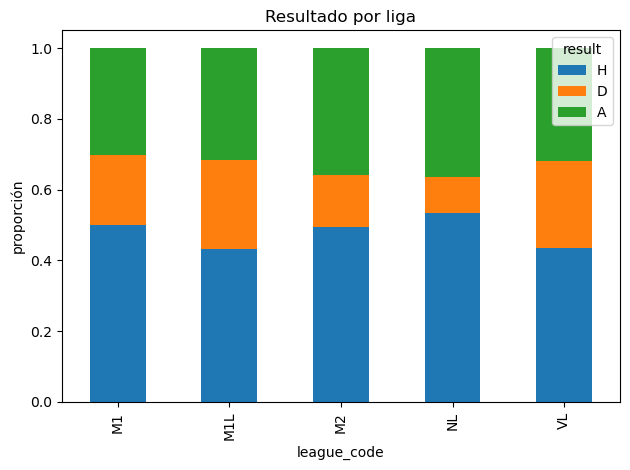

In [7]:
print("H/D/A global:", df.result.value_counts(normalize=True)[["H","D","A"]].round(3).to_dict())
print("goles prom  local:", round(df.home_goals.mean(),2), " visita:", round(df.away_goals.mean(),2),
      " (ventaja +%.2f)" % (df.home_goals.mean()-df.away_goals.mean()))

by_league = (df.groupby("league_code").result.value_counts(normalize=True)
               .unstack()[["H","D","A"]].round(3))
print(by_league)
by_league.plot(kind="bar", stacked=True)
plt.title("Resultado por liga"); plt.ylabel("proporción"); plt.tight_layout(); plt.show()

## 2. Feature *point-in-time*: Δppg (puntos por partido)

Para cada partido, calcula los PPG de cada equipo usando **solo sus partidos
anteriores** dentro de la misma temporada/liga/grupo (sin leakage). `Δppg =
ppg_local − ppg_visita`.

In [8]:
def point_in_time_ppg(matches):
    long = loader.to_team_long(matches).dropna(subset=["gf","ga"]).sort_values("date").copy()
    g = long.groupby(["season","league_code","group_id","team_id"], sort=False)
    long["pts_before"]   = g["points"].cumsum() - long["points"]   # puntos ANTES de este partido
    long["games_before"] = g.cumcount()                            # PJ antes (0 = primer partido)
    long["ppg_before"]   = long["pts_before"] / long["games_before"].replace(0, np.nan)
    home = (long[long.venue=="home"][["match_id","ppg_before","games_before"]]
            .rename(columns={"ppg_before":"ppg_home","games_before":"gp_home"}))
    away = (long[long.venue=="away"][["match_id","ppg_before","games_before"]]
            .rename(columns={"ppg_before":"ppg_away","games_before":"gp_away"}))
    feat = matches.merge(home, on="match_id").merge(away, on="match_id")
    feat["delta_ppg"] = feat["ppg_home"] - feat["ppg_away"]
    feat["y"] = feat["result"]
    return feat

feat = point_in_time_ppg(df)
feat[["date","league_code","home_team","away_team","gp_home","gp_away","delta_ppg","y"]].head()

,date,league_code,home_team,away_team,gp_home,gp_away,delta_ppg,y
0,2026-04-04,VL,Football Club International Turku,Vaasan Palloseura,0,0,NaN,D
1,2026-04-04,VL,Helsingin Jalkapalloklubin Liiga-HJK,SEINÄJOEN JALKAPALLOKERHO,0,0,NaN,H
2,2026-04-04,VL,IFK Mariehamn Fotboll,TPS Juniorijalkapallo,0,0,NaN,D
3,2026-04-04,VL,Ilves,Kuopion Palloseura,0,0,NaN,A
4,2026-04-04,VL,Fotbollsföreningen JARO Jalkapalloseura,FC Lahti,0,0,NaN,A


## 3. La curva estrella: H/D/A empírico vs Δppg

y                H     D     A
bin                           
(-3.0, -1.5]  0.23  0.15  0.63
(-1.5, -1.0]  0.28  0.21  0.51
(-1.0, -0.5]  0.36  0.19  0.45
(-0.5, -0.2]  0.42  0.25  0.33
(-0.2, 0.2]   0.51  0.21  0.28
(0.2, 0.5]    0.51  0.22  0.27
(0.5, 1.0]    0.64  0.15  0.21
(1.0, 1.5]    0.78  0.09  0.13
(1.5, 3.0]    0.70  0.21  0.09


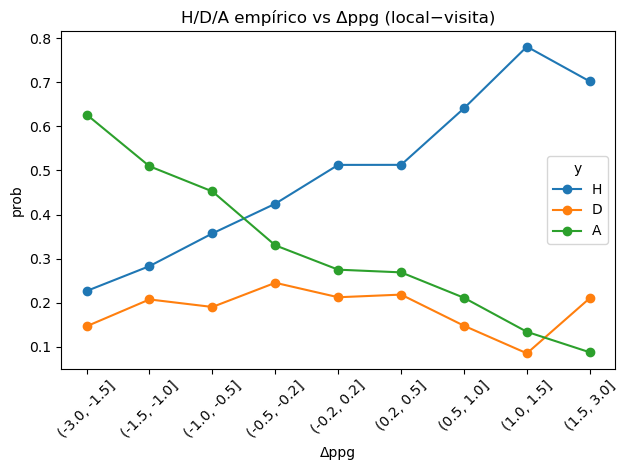

In [9]:
m = feat.dropna(subset=["delta_ppg"]).copy()
m = m[(m.gp_home>=2) & (m.gp_away>=2)]               # pedí algo de historia
bins = [-3,-1.5,-1,-0.5,-0.2,0.2,0.5,1,1.5,3]
m["bin"] = pd.cut(m.delta_ppg, bins)
curve = (m.groupby("bin", observed=True).y.value_counts(normalize=True)
           .unstack().reindex(columns=["H","D","A"]))
print(curve.round(2))
curve.plot(marker="o")
plt.title("H/D/A empírico vs Δppg (local−visita)"); plt.xlabel("Δppg"); plt.ylabel("prob")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

absbin
(0.0, 0.2]    0.230
(0.2, 0.5]    0.225
(0.5, 1.0]    0.174
(1.0, 1.5]    0.141
(1.5, 3.0]    0.184
dtype: float64


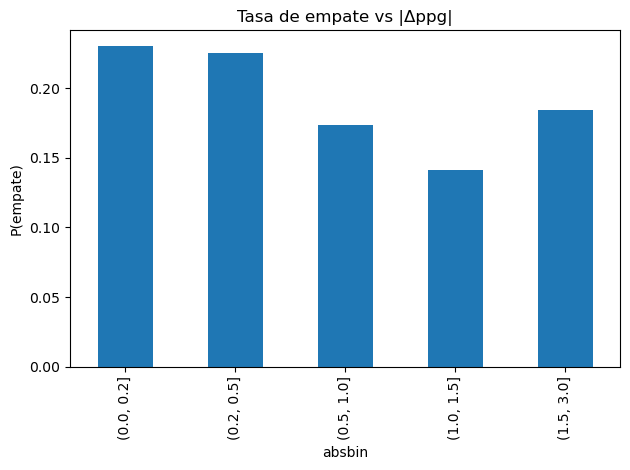

In [10]:
# ¿El empate es más probable cuando están parejos?
m["abs_delta"] = m.delta_ppg.abs()
m["absbin"] = pd.cut(m.abs_delta, [0,0.2,0.5,1,1.5,3])
draw = m.groupby("absbin", observed=True).apply(lambda d: (d.y=="D").mean())
print(draw.round(3))
draw.plot(kind="bar"); plt.title("Tasa de empate vs |Δppg|"); plt.ylabel("P(empate)")
plt.tight_layout(); plt.show()

## 4. Modelos y evaluación

- **B0**: tasa base por liga (de 2025).
- **B2**: logística multinomial sobre `Δppg`.

Métricas: **RPS** (ordinal H>D>A) y **log-loss**.

In [11]:
ORDER = ["H","D","A"]

def rps(probs, y, order=ORDER):
    P  = np.cumsum(np.asarray(probs, dtype=float), axis=1)
    idx = {c:i for i,c in enumerate(order)}
    Y = np.zeros((len(y), len(order)))
    for r,o in enumerate(y): Y[r, idx[o]] = 1
    Yc = np.cumsum(Y, axis=1)
    return float(np.mean(((P-Yc)**2).sum(axis=1) / (len(order)-1)))

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression

train = feat[feat.season==2025].dropna(subset=["delta_ppg"]).copy()
test  = feat[feat.season==2026].dropna(subset=["delta_ppg"]).copy()
test  = test[(test.gp_home>=2) & (test.gp_away>=2)]
print("train:", len(train), " test:", len(test))

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# B0 — tasa base por liga
rates = (train.groupby("league_code").y.value_counts(normalize=True)
              .unstack().reindex(columns=ORDER).fillna(0))
glob = train.y.value_counts(normalize=True).reindex(ORDER).fillna(0).values

def base_rate_probs(rows):
    out = []
    for _, r in rows.iterrows():
        out.append(rates.loc[r.league_code].values if r.league_code in rates.index else glob)
    return np.array(out, dtype=float)

P_base = base_rate_probs(test)

# B2 — logística multinomial sobre delta_ppg
clf = LogisticRegression(max_iter=1000)      # multinomial por defecto (solver lbfgs)
clf.fit(train[["delta_ppg"]].values, train.y.values)
cls = list(clf.classes_)
def to_order(P): return P[:, [cls.index(c) for c in ORDER]]
P_log = to_order(clf.predict_proba(test[["delta_ppg"]].values))

yt = test.y.values
print("RPS      base: %.4f | logística: %.4f" % (rps(P_base,yt), rps(P_log,yt)))
print("log-loss base: %.4f | logística: %.4f" % (log_loss(yt,P_base,labels=ORDER),
                                                  log_loss(yt,P_log,labels=ORDER)))

In [ ]:
# Interpretación: cómo mapea el modelo Δppg -> P(1X2)
print("clases:", clf.classes_, " coef:", clf.coef_.ravel().round(3))
xs = np.linspace(-2, 2, 60).reshape(-1,1)
pr = to_order(clf.predict_proba(xs))
for i,c in enumerate(ORDER): plt.plot(xs.ravel(), pr[:,i], label=c)
plt.legend(); plt.title("P(1X2) del modelo vs Δppg"); plt.xlabel("Δppg"); plt.ylabel("prob")
plt.tight_layout(); plt.show()

In [ ]:
# Calibración de P(local)
from sklearn.calibration import calibration_curve
frac, mean = calibration_curve((yt=="H").astype(int), P_log[:,0], n_bins=8, strategy="quantile")
plt.plot(mean, frac, "o-"); plt.plot([0,1],[0,1],"--")
plt.title("Calibración P(local)"); plt.xlabel("predicho"); plt.ylabel("observado")
plt.tight_layout(); plt.show()

In [ ]:
# Debilidad de principio de temporada: RPS por PJ previos disponibles
t2 = test.reset_index(drop=True).copy()
t2["min_pj"] = np.minimum(t2.gp_home, t2.gp_away)
t2["gpbin"] = pd.cut(t2.min_pj, [1,3,6,10,40])
P2 = to_order(clf.predict_proba(t2[["delta_ppg"]].values))
out = []
for b, idx in t2.groupby("gpbin", observed=True).groups.items():
    idx = list(idx)
    out.append((str(b), len(idx), round(rps(P2[idx], t2.loc[idx,"y"].values),4)))
print(pd.DataFrame(out, columns=["min PJ previos","n","RPS"]).to_string(index=False))

## 5. Predecir los fixtures de hoy

In [ ]:
today = loader.load_today()
cur = loader.to_team_long(df[df.season==2026]).dropna(subset=["gf","ga"])
ppg = cur.groupby("team_id").apply(lambda d: d.points.sum()/len(d)).rename("ppg")

def predict_row(r):
    ah, aw = ppg.get(r.home_team_id, np.nan), ppg.get(r.away_team_id, np.nan)
    d = ah - aw
    if pd.isna(d):
        p = rates.loc[r.league_code].values if r.league_code in rates.index else glob
    else:
        p = to_order(clf.predict_proba([[d]]))[0]
    return pd.Series({"Δppg": round(d,2) if pd.notna(d) else np.nan,
                      "P(H)": round(p[0],2), "P(D)": round(p[1],2), "P(A)": round(p[2],2)})

if len(today):
    pred = today.join(today.apply(predict_row, axis=1))
    print(pred[["home_team","away_team","Δppg","P(H)","P(D)","P(A)"]].to_string(index=False))
else:
    print("No hay fixtures en today_fixtures.csv (regenerá con build_dataset.py un día con partidos).")

## 6. Para leer / próximos pasos

- Si la **logística le gana al base rate** en RPS y log-loss → la tabla aporta señal (esperable).
- Mirá **dónde G0 falla**: (a) principio de temporada (RPS peor con pocos PJ), (b) los **empates** (casi planos), (c) ignora goles/forma/H2H.
- Esos huecos son lo que **G1** (Poisson / Dixon-Coles + shrinkage) viene a tapar.
- Comparalo contra el backtest heurístico del bot (`monitors/peak_backtest.py`).